# NLP Comparison: Traditional Libraries vs LLM (Gemini)

**Before running this notebook:**
1. Run `python traditional_nlp.py` (produces `results/*.csv`)
2. Run `python export_for_llm.py` (produces `llm_input/*.csv`)
3. Use prompts from `prompts.md` in Google AI Studio, save outputs to `llm_output/*.csv`

In [20]:
import os
import csv
import pandas as pd
from collections import Counter

def load_csv(path):
    """Load a CSV file as a list of dicts."""
    if not os.path.exists(path):
        print(f"[!] File not found: {path}")
        return None
    with open(path, "r", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def accuracy(matches, total):
    if total == 0:
        return 0.0
    return round(100 * matches / total, 1)

# Check that required folders exist
for folder in ["results", "llm_output"]:
    if os.path.isdir(folder):
        print(f"[OK] {folder}/ found")
    else:
        print(f"[!!] {folder}/ NOT found — make sure you ran the previous steps")

[OK] results/ found
[OK] llm_output/ found


---
## 1. Sentiment Analysis Comparison

In [21]:
trad = load_csv("results/sentiment_traditional.csv")
llm = load_csv("llm_output/sentiment.csv")

if trad and llm:
    llm_map = {row["id"]: row["label"].strip().lower() for row in llm}

    rows = []
    for row in trad:
        tid = row["id"]
        t_label = row["label"].strip().lower()
        l_label = llm_map.get(tid, "???")
        rows.append({
            "ID": tid,
            "Text": row["text"][:60] + "...",
            "Traditional (VADER)": t_label,
            "LLM (Gemini)": l_label,
            "Match": "Yes" if t_label == l_label else "No"
        })

    df_sent = pd.DataFrame(rows)
    agree = sum(1 for r in rows if r["Match"] == "Yes")
    total = len(rows)
    print(f"Agreement: {agree}/{total} ({accuracy(agree, total)}%)\n")
    display(df_sent)
else:
    print("Skipping — missing file(s)")

Agreement: 12899/20000 (64.5%)



,ID,Text,Traditional (VADER),LLM (Gemini),Match
0,1,director peter kosminsky gives these women a f...,positive,positive,Yes
1,2,what 's best about drumline is its energy ...,positive,positive,Yes
2,3,"haphazard , and inconsequential romantic ...",positive,negative,No
3,4,confident filmmaking and a pair of fascinating...,positive,positive,Yes
4,5,unfaithful ...,positive,negative,No
...,...,...,...,...,...
19995,19996,the rich performances by friel -- and especial...,positive,positive,Yes
19996,19997,"the performances are strong , though the subje...",positive,positive,Yes
19997,19998,to squeeze the action and our emotions into th...,positive,negative,No
19998,19999,i 'll buy the soundtrack . ...,positive,positive,Yes


### Sentiment accuracy vs ground truth

This cell uses `sentiment_ground_truth` from `datasets.py` to compute:
- Traditional VADER accuracy vs gold labels
- LLM (Gemini) accuracy vs the same gold labels

In [22]:
# Reload so we get the same dataset size as the pipeline (20k); otherwise the kernel
# may have a stale import with only 20 samples (old docstring said "20 sentences").
import importlib
import custom_datasets
importlib.reload(custom_datasets)
gold = [g.strip().lower() for g in custom_datasets.sentiment_ground_truth]

if trad and llm:
    trad_labels = [row["label"].strip().lower() for row in trad]
    llm_labels = [llm_map.get(row["id"], "").strip().lower() for row in trad]

    # Align lengths (CSV rows and ground truth must match; use min to avoid mismatch)
    n = min(len(gold), len(trad))
    if n < len(gold) or n < len(trad):
        print(f"Note: Using first {n} rows (gold={len(gold)}, trad={len(trad)}).\n")
    gold = gold[:n]
    trad_labels = trad_labels[:n]
    llm_labels = llm_labels[:n]
    trad_slice = trad[:n]

    trad_correct = sum(1 for t, g in zip(trad_labels, gold) if t == g)
    llm_correct = sum(1 for l, g in zip(llm_labels, gold) if l == g)
    trad_acc = accuracy(trad_correct, n)
    llm_acc = accuracy(llm_correct, n)

    print(f"Traditional (VADER) accuracy vs gold: {trad_correct}/{n} ({trad_acc}%)")
    print(f"LLM (Gemini) accuracy vs gold:       {llm_correct}/{n} ({llm_acc}%)\n")

    # Confusion matrices (binary: negative, positive)
    from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
    labels_cls = ["negative", "positive"]
    cm_trad = confusion_matrix(gold, trad_labels, labels=labels_cls)
    cm_llm = confusion_matrix(gold, llm_labels, labels=labels_cls)

    # Per-class metrics (precision, recall, F1)
    def per_class_df(y_true, y_pred, labels, name):
        P, R, F1, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
        return pd.DataFrame({
            "precision": P, "recall": R, "f1-score": F1
        }, index=labels).round(4).rename_axis(name)

    print("Per-class metrics — Traditional (VADER) vs Gold:")
    display(per_class_df(gold, trad_labels, labels_cls, "class"))
    print("Per-class metrics — LLM (Gemini) vs Gold:")
    display(per_class_df(gold, llm_labels, labels_cls, "class"))

    print("Confusion matrix — Traditional (VADER) vs Gold:")
    display(pd.DataFrame(cm_trad, index=labels_cls, columns=labels_cls))
    print("Confusion matrix — LLM (Gemini) vs Gold:")
    display(pd.DataFrame(cm_llm, index=labels_cls, columns=labels_cls))

    df_sent_gold = pd.DataFrame({
        "ID": list(range(1, n + 1)),
        "Text": [r["text"] for r in trad_slice],
        "Gold Label": gold,
        "Traditional (VADER)": trad_labels,
        "LLM (Gemini)": llm_labels,
    })
    display(df_sent_gold)
else:
    print("Run the previous sentiment comparison cell first.")

Traditional (VADER) accuracy vs gold: 13271/20000 (66.4%)
LLM (Gemini) accuracy vs gold:       17668/20000 (88.3%)

Per-class metrics — Traditional (VADER) vs Gold:


,precision,recall,f1-score
class,,,
negative,0.8369,0.4063,0.5470
positive,0.6080,0.9208,0.7324


Per-class metrics — LLM (Gemini) vs Gold:


,precision,recall,f1-score
class,,,
negative,0.8904,0.8744,0.8823
positive,0.8766,0.8924,0.8844


Confusion matrix — Traditional (VADER) vs Gold:


,negative,positive
negative,4063,5937
positive,792,9208


Confusion matrix — LLM (Gemini) vs Gold:


,negative,positive
negative,8744,1256
positive,1076,8924


,ID,Text,Gold Label,Traditional (VADER),LLM (Gemini)
0,1,director peter kosminsky gives these women a f...,positive,positive,positive
1,2,what 's best about drumline is its energy,positive,positive,positive
2,3,"haphazard , and inconsequential romantic",negative,positive,negative
3,4,confident filmmaking and a pair of fascinating...,positive,positive,positive
4,5,unfaithful,negative,positive,negative
...,...,...,...,...,...
19995,19996,the rich performances by friel -- and especial...,positive,positive,positive
19996,19997,"the performances are strong , though the subje...",positive,positive,positive
19997,19998,to squeeze the action and our emotions into th...,positive,positive,negative
19998,19999,i 'll buy the soundtrack .,positive,positive,positive


/var/folders/rj/cw0gsrgs3tgc7gl1n502wkq00000gn/T/ipykernel_72251/2196126309.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1])


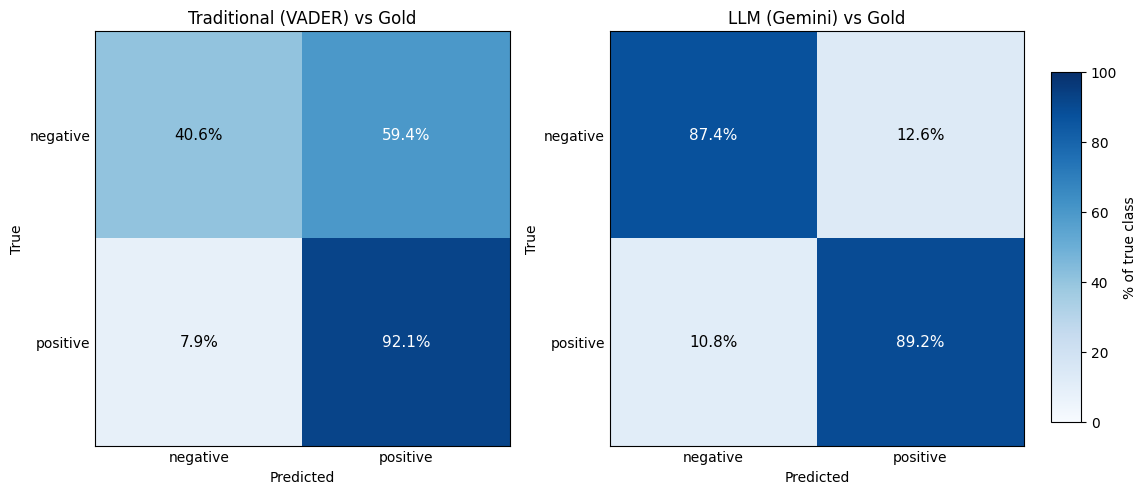

In [27]:
# Percentage-wise confusion matrices (row-normalized: % of each true class predicted as each label)
import matplotlib.pyplot as plt
import numpy as np

try:
    def pct_cm(cm):
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        return (100 * cm / row_sums).round(1)

    pct_trad = pct_cm(cm_trad)
    pct_llm = pct_cm(cm_llm)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, pct, title in zip(axes, [pct_trad, pct_llm], ["Traditional (VADER) vs Gold", "LLM (Gemini) vs Gold"]):
        im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
        ax.set_xticks(range(len(labels_cls)))
        ax.set_yticks(range(len(labels_cls)))
        ax.set_xticklabels(labels_cls)
        ax.set_yticklabels(labels_cls)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(title, fontsize=12)
        # Set a white background on the axes to prevent overlap with colorbar or other axes.
        ax.set_facecolor('white')
        # Write percent value in center, maximize legibility
        for i in range(len(labels_cls)):
            for j in range(len(labels_cls)):
                color = "black" if pct[i, j] < 50 else "white"
                ax.text(j, i, f"{pct[i, j]:.1f}%", ha="center", va="center", color=color, fontsize=11)
        # Minor ticks off for a cleaner look
        ax.tick_params(axis='both', which='both', length=0)
    # Place colorbar on right next to plots, not overlapping
    fig.subplots_adjust(right=0.85, wspace=0.3)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.025, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="% of true class")
    plt.tight_layout(rect=[0, 0, 0.87, 1])
    plt.show()
except NameError:
    print("Run the sentiment accuracy vs ground truth cell first.")

---
## 2. Named Entity Recognition (NER) Comparison

In [29]:
def normalize_entities(entities_str):
    """Normalize entities string into a set of (text_lower, type_upper) tuples."""
    entities = set()
    if not entities_str or entities_str.strip().upper() == "NONE":
        return entities
    for part in entities_str.split(";"):
        part = part.strip()
        if "(" in part and ")" in part:
            name = part[:part.rfind("(")].strip().lower()
            etype = part[part.rfind("(") + 1:part.rfind(")")].strip().upper()
            entities.add((name, etype))
    return entities

trad = load_csv("results/ner_traditional.csv")
llm = load_csv("llm_output/ner.csv")

if trad and llm:
    llm_map = {row["id"]: row["entities"] for row in llm}

    rows = []
    total_trad_ents = 0
    total_llm_ents = 0
    total_overlap = 0
    name_overlap = 0

    for row in trad:
        tid = row["id"]
        t_ents = normalize_entities(row["entities"])
        l_ents = normalize_entities(llm_map.get(tid, ""))

        t_names = {name for name, _ in t_ents}
        l_names = {name for name, _ in l_ents}

        overlap = t_ents & l_ents
        n_overlap = t_names & l_names

        total_trad_ents += len(t_ents)
        total_llm_ents += len(l_ents)
        total_overlap += len(overlap)
        name_overlap += len(n_overlap)

        rows.append({
            "ID": tid,
            "Text": row["text"][:45] + "...",
            "Traditional (spaCy)": row["entities"],
            "LLM (Gemini)": llm_map.get(tid, "N/A"),
            "Exact Match": f"{len(overlap)}/{max(len(t_ents), len(l_ents))}"
        })

    df_ner = pd.DataFrame(rows)
    denom = max(total_trad_ents, total_llm_ents) or 1
    exact_pct = accuracy(total_overlap, denom)
    name_pct = accuracy(name_overlap, denom)
    print(f"Entity exact match (name+type): {total_overlap}/{denom} ({exact_pct}%)")
    print(f"Entity name-only match:         {name_overlap}/{denom} ({name_pct}%)\n")
    display(df_ner.head(20) if len(df_ner) > 20 else df_ner)
    if len(df_ner) > 20:
        print(f"... ({len(df_ner)} rows total)")
else:
    print("Skipping — missing file(s)")

Entity exact match (name+type): 932/2422 (38.5%)
Entity name-only match:         1149/2422 (47.4%)



,ID,Text,Traditional (spaCy),LLM (Gemini),Exact Match
0,1,Medicaid would be at risk of being taken away...,Medicaid (ORG),Medicaid (MISC),0/1
1,2,BUDAPEST 1996-08-26...,1996-08-26 (MISC),BUDAPEST (LOC),0/1
2,3,Result : England won by five wickets ....,England (LOC); five (MISC),England (LOC),1/2
3,4,The fifth- seeded Majoli joined Anke Huber ( ...,Majoli (LOC); Anke Huber (PER); 5 (MISC); Magd...,Majoli (PER); Anke Huber (PER); Magdalena Male...,2/5
4,5,"DBRS confirms Power Corp , Power Financial ra...",DBRS confirms Power Corp (ORG); Power Financia...,DBRS (ORG); Power Corp (ORG); Power Financial ...,1/3
5,6,+5 Sigeki Maruyama ( Japan ) through 17...,Japan (LOC); 17 (MISC),Sigeki Maruyama (PER); Japan (LOC),1/2
6,7,Books close September 23-27...,September 23-27 (MISC),NONE,0/1
7,8,They finally went ahead with an escort from t...,NONE,ULIMO-J (ORG),0/1
8,9,The government had been threatening to fire t...,Tuesday (MISC),NONE,0/1
9,10,Australia foreign minister arrives in China ....,Australia (LOC); China (LOC),Australia (LOC); China (LOC),2/2


... (1000 rows total)


### NER accuracy vs ground truth (CoNLL-2003)

This cell uses `ner_ground_truth` from CoNLL-2003 to compute entity-level precision, recall, and F1 for Traditional (spaCy) and LLM (Gemini). Entity types are normalized (e.g. PERSON/PER, GPE→LOC) for comparison.

In [33]:
# NER vs gold: load data (same as previous cell if you ran it; otherwise load here)
import importlib
import custom_datasets
importlib.reload(custom_datasets)
ner_gold_raw = list(custom_datasets.ner_ground_truth)

trad_ner = load_csv("results/ner_traditional.csv")
llm_ner = load_csv("llm_output/ner.csv")

# Normalize entity type for comparison (CoNLL: PER, ORG, LOC, MISC; spaCy: PERSON, ORG, GPE, LOC; LLM: PERSON, ORG, GPE, etc.)
def norm_type(t):
    t = (t or "").strip().upper()
    if t in ("PERSON", "PER"):
        return "PER"
    if t in ("ORG",):
        return "ORG"
    if t in ("LOC", "GPE", "FAC", "LOCATION"):
        return "LOC"
    return "MISC"  # MISC and anything else

def normalize_entities_for_gold(entities_str, type_norm=True):
    """Return set of (text_lower, type_normalized) tuples."""
    entities = set()
    if not entities_str or entities_str.strip().upper() == "NONE":
        return entities
    for part in entities_str.split(";"):
        part = part.strip()
        if "(" in part and ")" in part:
            name = part[:part.rfind("(")].strip().lower()
            etype = part[part.rfind("(") + 1:part.rfind(")")].strip().upper()
            if type_norm:
                etype = norm_type(etype)
            entities.add((name, etype))
    return entities

if trad_ner and ner_gold_raw:
    n_ner = min(len(ner_gold_raw), len(trad_ner))
    if n_ner < len(ner_gold_raw) or n_ner < len(trad_ner):
        print(f"Note: Using first {n_ner} rows (gold={len(ner_gold_raw)}, trad={len(trad_ner)}).\n")
    gold_ents_list = [normalize_entities_for_gold(g) for g in ner_gold_raw[:n_ner]]
    trad_ents_list = [normalize_entities_for_gold(row["entities"]) for row in trad_ner[:n_ner]]
    llm_map_ner = {row["id"]: row["entities"] for row in llm_ner} if llm_ner else {}
    llm_ents_list = [normalize_entities_for_gold(llm_map_ner.get(row["id"], "")) for row in trad_ner[:n_ner]] if llm_map_ner else []

    def entity_prf1(pred_sets, gold_sets):
        tp = fp = fn = 0
        for pred, gold in zip(pred_sets, gold_sets):
            pred, gold = set(pred), set(gold)
            tp += len(pred & gold)
            fp += len(pred - gold)
            fn += len(gold - pred)
        p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        return {"precision": round(p, 4), "recall": round(r, 4), "f1": round(f1, 4), "tp": tp, "fp": fp, "fn": fn}

    res_trad = entity_prf1(trad_ents_list, gold_ents_list)
    print("Traditional (spaCy) vs Gold (entity-level):")
    print(f"  Precision: {res_trad['precision']:.2%}  Recall: {res_trad['recall']:.2%}  F1: {res_trad['f1']:.2%}\n")
    if llm_ents_list:
        res_llm = entity_prf1(llm_ents_list, gold_ents_list)
        print("LLM (Gemini) vs Gold (entity-level):")
        print(f"  Precision: {res_llm['precision']:.2%}  Recall: {res_llm['recall']:.2%}  F1: {res_llm['f1']:.2%}\n")

    # Per-entity-type metrics (PER, ORG, LOC, MISC)
    types_order = ["PER", "ORG", "LOC", "MISC"]
    def prf1_by_type(pred_sets, gold_sets):
        by_type = {t: {"tp": 0, "fp": 0, "fn": 0} for t in types_order}
        for pred, gold in zip(pred_sets, gold_sets):
            for t in types_order:
                pred_t = {(n, typ) for n, typ in pred if typ == t}
                gold_t = {(n, typ) for n, typ in gold if typ == t}
                by_type[t]["tp"] += len(pred_t & gold_t)
                by_type[t]["fp"] += len(pred_t - gold_t)
                by_type[t]["fn"] += len(gold_t - pred_t)
        rows = []
        for t in types_order:
            d = by_type[t]
            tp, fp, fn = d["tp"], d["fp"], d["fn"]
            p = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            r = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
            rows.append({"type": t, "precision": round(p, 4), "recall": round(r, 4), "f1": round(f1, 4)})
        return pd.DataFrame(rows)

    print("Per-entity-type (Traditional vs Gold):")
    display(prf1_by_type(trad_ents_list, gold_ents_list))
    if llm_ents_list:
        print("Per-entity-type (LLM vs Gold):")
        display(prf1_by_type(llm_ents_list, gold_ents_list))

    # Confusion matrices (entity-type): rows = gold type, cols = predicted type (only entities with matching span)
    def entity_type_confusion_matrix(gold_sets, pred_sets, labels):
        cm = np.zeros((len(labels), len(labels)))
        label_idx = {t: i for i, t in enumerate(labels)}
        for gold_set, pred_set in zip(gold_sets, pred_sets):
            gold_set, pred_set = set(gold_set), set(pred_set)
            pred_by_name = {}  # name -> pred_type (one per name if multiple we take last)
            for (n, t) in pred_set:
                pred_by_name[n] = t
            for (name, gtype) in gold_set:
                if name in pred_by_name:
                    ptype = pred_by_name[name]
                    i, j = label_idx.get(gtype, 0), label_idx.get(ptype, 0)
                    cm[i, j] += 1
        return cm

    import numpy as np
    types_order = ["PER", "ORG", "LOC", "MISC"]
    cm_trad_ner = entity_type_confusion_matrix(gold_ents_list, trad_ents_list, types_order)
    print("Confusion matrix — Traditional (spaCy) vs Gold (entity type, span-matched only):")
    display(pd.DataFrame(cm_trad_ner.astype(int), index=types_order, columns=types_order))
    if llm_ents_list:
        cm_llm_ner = entity_type_confusion_matrix(gold_ents_list, llm_ents_list, types_order)
        print("Confusion matrix — LLM (Gemini) vs Gold (entity type, span-matched only):")
        display(pd.DataFrame(cm_llm_ner.astype(int), index=types_order, columns=types_order))

    # Sample table: first 10 rows with Text, Gold, Traditional, LLM
    sample = 10
    df_ner_gold = pd.DataFrame({
        "ID": list(range(1, sample + 1)),
        "Text": [trad_ner[i]["text"][:60] + "..." for i in range(sample)],
        "Gold": [ner_gold_raw[i] for i in range(sample)],
        "Traditional (spaCy)": [trad_ner[i]["entities"] for i in range(sample)],
        "LLM (Gemini)": [llm_map_ner.get(trad_ner[i]["id"], "N/A") for i in range(sample)] if llm_map_ner else ["N/A"] * sample,
    })
    display(df_ner_gold)
else:
    print("Run traditional_nlp.py and ensure results/ner_traditional.csv exists. For LLM metrics, add llm_output/ner_llm.csv.")

Traditional (spaCy) vs Gold (entity-level):
  Precision: 37.94%  Recall: 56.83%  F1: 45.51%

LLM (Gemini) vs Gold (entity-level):
  Precision: 92.79%  Recall: 94.68%  F1: 93.73%

Per-entity-type (Traditional vs Gold):


,type,precision,recall,f1
0,PER,0.7132,0.6539,0.6823
1,ORG,0.4215,0.3269,0.3682
2,LOC,0.7901,0.7292,0.7584
3,MISC,0.1035,0.5580,0.1746


Per-entity-type (LLM vs Gold):


,type,precision,recall,f1
0,PER,0.9955,0.9955,0.9955
1,ORG,0.8956,0.9530,0.9234
2,LOC,0.9458,0.9458,0.9458
3,MISC,0.8282,0.8393,0.8337


Confusion matrix — Traditional (spaCy) vs Gold (entity type, span-matched only):


,PER,ORG,LOC,MISC
PER,291,43,11,5
ORG,34,153,37,8
LOC,17,26,350,6
MISC,4,25,6,125


Confusion matrix — LLM (Gemini) vs Gold (entity type, span-matched only):


,PER,ORG,LOC,MISC
PER,443,0,1,0
ORG,0,446,2,7
LOC,0,12,454,3
MISC,1,3,2,188


,ID,Text,Gold,Traditional (spaCy),LLM (Gemini)
0,1,Medicaid would be at risk of being taken away ...,Medicaid (MISC),Medicaid (ORG),Medicaid (MISC)
1,2,BUDAPEST 1996-08-26...,BUDAPEST (LOC),1996-08-26 (MISC),BUDAPEST (LOC)
2,3,Result : England won by five wickets ....,England (LOC),England (LOC); five (MISC),England (LOC)
3,4,The fifth- seeded Majoli joined Anke Huber ( 5...,Majoli (PER); Anke Huber (PER); Magdalena Male...,Majoli (LOC); Anke Huber (PER); 5 (MISC); Magd...,Majoli (PER); Anke Huber (PER); Magdalena Male...
4,5,"DBRS confirms Power Corp , Power Financial rat...",DBRS (ORG); Power Corp (ORG); Power (ORG),DBRS confirms Power Corp (ORG); Power Financia...,DBRS (ORG); Power Corp (ORG); Power Financial ...
5,6,+5 Sigeki Maruyama ( Japan ) through 17...,Sigeki Maruyama (PER); Japan (LOC),Japan (LOC); 17 (MISC),Sigeki Maruyama (PER); Japan (LOC)
6,7,Books close September 23-27...,NONE,September 23-27 (MISC),NONE
7,8,They finally went ahead with an escort from th...,ULIMO-J (ORG),NONE,ULIMO-J (ORG)
8,9,The government had been threatening to fire th...,NONE,Tuesday (MISC),NONE
9,10,Australia foreign minister arrives in China ....,Australia (LOC); China (LOC),Australia (LOC); China (LOC),Australia (LOC); China (LOC)


/var/folders/rj/cw0gsrgs3tgc7gl1n502wkq00000gn/T/ipykernel_72251/356278253.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.87, 1])


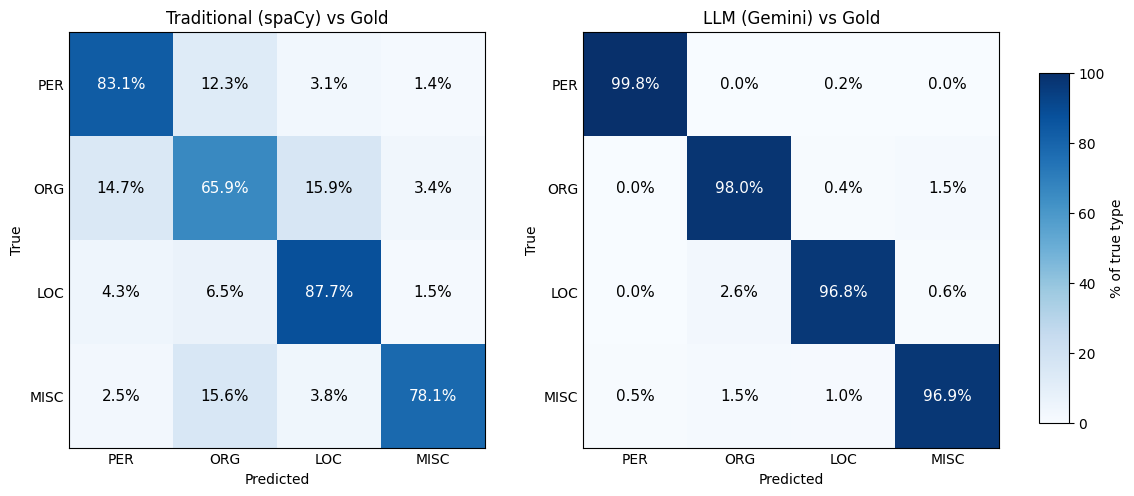

In [34]:
# NER: Percentage-wise confusion matrices (row-normalized: % of each gold type predicted as each type)
import matplotlib.pyplot as plt
import numpy as np

try:
    types_order = ["PER", "ORG", "LOC", "MISC"]
    def pct_cm(cm):
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        return (100 * cm / row_sums).round(1)

    pct_trad_ner = pct_cm(cm_trad_ner)
    pct_llm_ner = pct_cm(cm_llm_ner) if llm_ents_list else None

    n_plots = 2 if pct_llm_ner is not None else 1
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    for ax, pct, title in zip(axes, [pct_trad_ner, pct_llm_ner], ["Traditional (spaCy) vs Gold", "LLM (Gemini) vs Gold"]):
        if pct is None:
            continue
        im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
        ax.set_xticks(range(len(types_order)))
        ax.set_yticks(range(len(types_order)))
        ax.set_xticklabels(types_order)
        ax.set_yticklabels(types_order)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(title, fontsize=12)
        ax.set_facecolor("white")
        for i in range(len(types_order)):
            for j in range(len(types_order)):
                color = "black" if pct[i, j] < 50 else "white"
                ax.text(j, i, f"{pct[i, j]:.1f}%", ha="center", va="center", color=color, fontsize=11)
        ax.tick_params(axis="both", which="both", length=0)
    fig.subplots_adjust(right=0.85, wspace=0.3)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.025, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="% of true type")
    plt.tight_layout(rect=[0, 0, 0.87, 1])
    plt.show()
except NameError:
    print("Run the NER accuracy vs ground truth cell first.")

---
## 3. POS Tagging Comparison

### POS accuracy vs ground truth (CoNLL-2003)

This cell uses `pos_ground_truth` from CoNLL-2003 (Penn Treebank tags) to compute token-level accuracy and confusion matrices for Traditional (NLTK) and LLM (Gemini). Tags are aligned by position (min length) per sentence.

In [35]:
# POS vs gold: load data
import importlib
import numpy as np
import custom_datasets
importlib.reload(custom_datasets)
pos_gold_raw = list(custom_datasets.pos_ground_truth)

trad_pos = load_csv("results/pos_traditional.csv")
llm_pos = load_csv("llm_output/pos_llm.csv")

def parse_pos_tags(pos_str):
    """Parse 'w1/T1 w2/T2 ...' to list of tags (order preserved)."""
    if not pos_str or not pos_str.strip():
        return []
    tags = []
    for pair in pos_str.split():
        if "/" in pair:
            tags.append(pair.rsplit("/", 1)[1])
        else:
            tags.append("")
    return tags

if trad_pos and pos_gold_raw:
    n_pos = min(len(pos_gold_raw), len(trad_pos))
    if n_pos < len(pos_gold_raw) or n_pos < len(trad_pos):
        print(f"Note: Using first {n_pos} rows (gold={len(pos_gold_raw)}, trad={len(trad_pos)}).\n")
    gold_pos_list = [parse_pos_tags(pos_gold_raw[i]) for i in range(n_pos)]
    trad_pos_list = [parse_pos_tags(trad_pos[i]["pos_tags"]) for i in range(n_pos)]
    llm_map_pos = {row["id"]: row["pos_tags"] for row in llm_pos} if llm_pos else {}
    llm_pos_list = [parse_pos_tags(llm_map_pos.get(trad_pos[i]["id"], "")) for i in range(n_pos)] if llm_map_pos else []

    pairs_trad = []
    for i in range(n_pos):
        g, t = gold_pos_list[i], trad_pos_list[i]
        for j in range(min(len(g), len(t))):
            pairs_trad.append((g[j], t[j]))
    correct_trad = sum(1 for g, p in pairs_trad if g == p)
    total_trad = len(pairs_trad)

    print("Traditional (NLTK) vs Gold (token-level):")
    print(f"  Accuracy: {correct_trad}/{total_trad} ({100*correct_trad/total_trad if total_trad else 0:.2f}%)\n")
    if llm_map_pos:
        pairs_llm = []
        for i in range(n_pos):
            g, t = gold_pos_list[i], llm_pos_list[i]
            for j in range(min(len(g), len(t))):
                pairs_llm.append((g[j], t[j]))
        correct_llm = sum(1 for g, p in pairs_llm if g == p)
        total_llm = len(pairs_llm)
        print("LLM (Gemini) vs Gold (token-level):")
        print(f"  Accuracy: {correct_llm}/{total_llm} ({100*correct_llm/total_llm if total_llm else 0:.2f}%)\n")

    # Confusion matrix: all (gold_tag, pred_tag) pairs; use sorted unique tags
    all_gold_tags = sorted(set(g for g, p in pairs_trad))
    all_pred_tags = sorted(set(p for g, p in pairs_trad))
    tag_set = sorted(set(all_gold_tags) | set(all_pred_tags))
    tag_idx = {t: i for i, t in enumerate(tag_set)}
    cm_trad_pos = np.zeros((len(tag_set), len(tag_set)))
    for g, p in pairs_trad:
        i, j = tag_idx.get(g, 0), tag_idx.get(p, 0)
        cm_trad_pos[i, j] += 1
    print("Confusion matrix — Traditional (NLTK) vs Gold (top 12 tags by gold frequency):")
    gold_freq = sorted([(t, sum(1 for g, _ in pairs_trad if g == t)) for t in tag_set], key=lambda x: -x[1])
    top_tags = [t for t, _ in gold_freq[:12]]
    idx_top = {t: i for i, t in enumerate(top_tags)}
    cm_top = np.zeros((len(top_tags), len(top_tags)))
    for g, p in pairs_trad:
        if g in idx_top and p in idx_top:
            cm_top[idx_top[g], idx_top[p]] += 1
    display(pd.DataFrame(cm_top.astype(int), index=top_tags, columns=top_tags))
    if llm_map_pos:
        cm_llm_pos = np.zeros((len(tag_set), len(tag_set)))
        for g, p in pairs_llm:
            i, j = tag_idx.get(g, 0), tag_idx.get(p, 0)
            cm_llm_pos[i, j] += 1
        print("Confusion matrix — LLM (Gemini) vs Gold (top 12 tags):")
        cm_top_llm = np.zeros((len(top_tags), len(top_tags)))
        for g, p in pairs_llm:
            if g in idx_top and p in idx_top:
                cm_top_llm[idx_top[g], idx_top[p]] += 1
        display(pd.DataFrame(cm_top_llm.astype(int), index=top_tags, columns=top_tags))

    # Sample table
    sample = 5
    df_pos_gold = pd.DataFrame({
        "ID": list(range(1, sample + 1)),
        "Text": [trad_pos[i]["text"][:50] + "..." for i in range(sample)],
        "Gold (excerpt)": [pos_gold_raw[i][:60] + "..." for i in range(sample)],
        "Traditional (excerpt)": [trad_pos[i]["pos_tags"][:60] + "..." for i in range(sample)],
        "LLM (excerpt)": [llm_map_pos.get(trad_pos[i]["id"], "N/A")[:60] + "..." for i in range(sample)] if llm_map_pos else ["N/A"] * sample,
    })
    display(df_pos_gold)
else:
    print("Run traditional_nlp.py --tasks pos and ensure results/pos_traditional.csv exists.")

[!] File not found: llm_output/pos_llm.csv
Traditional (NLTK) vs Gold (token-level):
  Accuracy: 12377/14036 (88.18%)

Confusion matrix — Traditional (NLTK) vs Gold (top 12 tags by gold frequency):


,NNP,NN,CD,IN,DT,JJ,NNS,VBD,.,",",VB,VBN
NNP,2181,43,14,6,1,52,17,3,42,0,4,1
NN,94,1432,6,5,5,40,21,4,0,0,14,2
CD,19,18,1173,1,0,120,10,5,0,0,3,0
IN,15,4,1,1246,3,0,5,0,0,0,2,0
DT,1,0,0,8,907,0,0,1,0,0,1,0
JJ,69,47,13,1,0,555,3,7,0,0,6,6
NNS,51,15,6,1,2,2,633,1,0,0,1,0
VBD,3,4,0,0,0,1,0,566,0,0,0,26
.,3,1,1,0,0,0,2,0,516,0,0,0
",",3,1,0,0,0,0,0,0,0,450,0,0


,ID,Text,Gold (excerpt),Traditional (excerpt),LLM (excerpt)
0,1,Medicaid would be at risk of being taken away ...,Medicaid/NNP would/MD be/VB at/IN risk/NN of/I...,Medicaid/NNP would/MD be/VB at/IN risk/NN of/I...,N/A
1,2,BUDAPEST 1996-08-26...,BUDAPEST/RB 1996-08-26/CD...,BUDAPEST/IN 1996-08-26/JJ...,N/A
2,3,Result : England won by five wickets ....,Result/NN :/: England/NNP won/VBD by/IN five/C...,Result/NN :/: England/NNP won/VBD by/IN five/C...,N/A
3,4,The fifth- seeded Majoli joined Anke Huber ( 5...,The/DT fifth-/JJ seeded/VBN Majoli/NNP joined/...,The/DT fifth-/NN seeded/VBD Majoli/NNP joined/...,N/A
4,5,"DBRS confirms Power Corp , Power Financial rat...","DBRS/NNS confirms/VBZ Power/NNP Corp/NNP ,/, P...","DBRS/NNP confirms/VBZ Power/NNP Corp/NNP ,/, P...",N/A


In [ ]:
# POS: Percentage-wise confusion matrices (top 12 tags, row-normalized)
import matplotlib.pyplot as plt
import numpy as np

try:
    def pct_cm(cm):
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        return (100 * cm / row_sums).round(1)

    try:
        cm_list = [cm_top, cm_top_llm]
        title_list = ["Traditional (NLTK) vs Gold", "LLM (Gemini) vs Gold"]
    except NameError:
        cm_list = [cm_top]
        title_list = ["Traditional (NLTK) vs Gold"]
    n_plots = len(cm_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 6))
    if n_plots == 1:
        axes = [axes]
    for ax, cm, title in zip(axes, cm_list, title_list):
        pct = pct_cm(cm)
        im = ax.imshow(pct, cmap="Blues", vmin=0, vmax=100)
        ax.set_xticks(range(len(top_tags)))
        ax.set_yticks(range(len(top_tags)))
        ax.set_xticklabels(top_tags, rotation=45, ha="right")
        ax.set_yticklabels(top_tags)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(title, fontsize=12)
        ax.set_facecolor("white")
        for i in range(len(top_tags)):
            for j in range(len(top_tags)):
                color = "black" if pct[i, j] < 50 else "white"
                ax.text(j, i, f"{pct[i, j]:.0f}%", ha="center", va="center", color=color, fontsize=8)
        ax.tick_params(axis="both", which="both", length=0)
    fig.subplots_adjust(right=0.85, wspace=0.3, bottom=0.2)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.025, 0.7])
    fig.colorbar(im, cax=cbar_ax, label="% of true tag")
    plt.suptitle("POS tags (top 12 by gold frequency)", fontsize=11, y=1.02)
    plt.show()
except NameError:
    print("Run the POS accuracy vs ground truth cell first.")

In [ ]:
trad = load_csv("results/pos_traditional.csv")
llm = load_csv("llm_output/pos_llm.csv")

if trad and llm:
    llm_map = {row["id"]: row["pos_tags"] for row in llm}

    rows = []
    total_tokens = 0
    total_match = 0

    for row in trad:
        tid = row["id"]
        t_tags = row["pos_tags"].split()
        l_tags = llm_map.get(tid, "").split()

        # Build word -> tag dicts
        t_dict = {}
        for pair in t_tags:
            if "/" in pair:
                parts = pair.rsplit("/", 1)
                t_dict[parts[0].lower()] = parts[1]

        l_dict = {}
        for pair in l_tags:
            if "/" in pair:
                parts = pair.rsplit("/", 1)
                l_dict[parts[0].lower()] = parts[1]

        matches = 0
        compared = 0
        for word, tag in t_dict.items():
            if word in l_dict:
                compared += 1
                if l_dict[word] == tag:
                    matches += 1

        total_tokens += compared
        total_match += matches

        pct = accuracy(matches, compared) if compared > 0 else 0
        rows.append({
            "ID": tid,
            "Text": row["text"][:45] + "...",
            "Traditional (NLTK)": row["pos_tags"][:50] + "...",
            "LLM (Gemini)": llm_map.get(tid, "")[:50] + "...",
            "Token Match": f"{matches}/{compared} ({pct}%)"
        })

    df_pos = pd.DataFrame(rows)
    overall = accuracy(total_match, total_tokens)
    print(f"Overall token-level agreement: {total_match}/{total_tokens} ({overall}%)\n")
    display(df_pos)
else:
    print("Skipping — missing file(s)")

---
## 4. Topic Modelling Comparison

In [ ]:
trad = load_csv("results/topic_traditional.csv")
llm = load_csv("llm_output/topic_llm.csv")

if trad and llm:
    llm_map = {row["id"]: row["topic"].strip() for row in llm}

    # Map LDA numeric topic IDs to descriptive names via majority vote
    topic_id_to_llm_labels = {}
    for row in trad:
        tid = row["id"]
        topic_id = row["topic_id"]
        llm_label = llm_map.get(tid, "???")
        topic_id_to_llm_labels.setdefault(topic_id, []).append(llm_label)

    lda_to_name = {}
    for topic_id, labels in topic_id_to_llm_labels.items():
        most_common = Counter(labels).most_common(1)[0][0]
        lda_to_name[topic_id] = most_common

    # Show the mapping
    print("LDA Topic ID -> Mapped Name (majority vote from LLM labels):")
    mapping_rows = []
    for k, v in sorted(lda_to_name.items()):
        keywords = next((r["keywords"] for r in trad if r["topic_id"] == k), "")
        mapping_rows.append({"LDA Topic ID": k, "Top Keywords": keywords, "Mapped Name": v})
        print(f"  Topic {k} ({keywords}) -> {v}")
    print()

    # Build comparison table
    rows = []
    agree = 0
    for row in trad:
        tid = row["id"]
        topic_id = row["topic_id"]
        mapped = lda_to_name.get(topic_id, "???")
        llm_label = llm_map.get(tid, "???")
        match = mapped.lower() == llm_label.lower()
        if match:
            agree += 1
        rows.append({
            "ID": tid,
            "Text": row["text"][:55] + "...",
            "LDA Topic ID": topic_id,
            "LDA Mapped": mapped,
            "LLM (Gemini)": llm_label,
            "Match": "Yes" if match else "No"
        })

    df_topic = pd.DataFrame(rows)
    total = len(rows)
    acc = accuracy(agree, total)
    print(f"Agreement (after mapping): {agree}/{total} ({acc}%)\n")
    display(df_topic)
else:
    print("Skipping — missing file(s)")

---
## 5. Language Identification Comparison

In [ ]:
trad = load_csv("results/language_traditional.csv")
llm = load_csv("llm_output/language_llm.csv")

if trad and llm:
    llm_map = {row["id"]: row["language"].strip() for row in llm}

    rows = []
    agree = 0
    trad_correct = 0
    llm_correct = 0

    for row in trad:
        tid = row["id"]
        actual = row["actual"].strip()
        t_pred = row["predicted"].strip()
        l_pred = llm_map.get(tid, "???").strip()

        t_ok = t_pred.lower() == actual.lower()
        l_ok = l_pred.lower() == actual.lower()

        if t_pred.lower() == l_pred.lower():
            agree += 1
        if t_ok:
            trad_correct += 1
        if l_ok:
            llm_correct += 1

        rows.append({
            "ID": tid,
            "Text": row["text"][:40] + "...",
            "Actual": actual,
            "Traditional (langdetect)": t_pred,
            "LLM (Gemini)": l_pred,
            "Trad Correct": "Yes" if t_ok else "No",
            "LLM Correct": "Yes" if l_ok else "No"
        })

    df_lang = pd.DataFrame(rows)
    total = len(rows)
    print(f"Traditional accuracy: {trad_correct}/{total} ({accuracy(trad_correct, total)}%)")
    print(f"LLM accuracy:        {llm_correct}/{total} ({accuracy(llm_correct, total)}%)")
    print(f"Both agree:          {agree}/{total} ({accuracy(agree, total)}%)\n")
    display(df_lang)
else:
    print("Skipping — missing file(s)")

---
## Overall Summary

In [ ]:
summary_rows = []

# Sentiment
trad_s = load_csv("results/sentiment_traditional.csv")
llm_s = load_csv("llm_output/sentiment_llm.csv")
if trad_s and llm_s:
    llm_map_s = {r["id"]: r["label"].strip().lower() for r in llm_s}
    agree_s = sum(1 for r in trad_s if r["label"].strip().lower() == llm_map_s.get(r["id"], ""))
    summary_rows.append({"Task": "Sentiment Analysis", "Metric": "Label Agreement",
                         "Match": agree_s, "Total": len(trad_s),
                         "Percentage": f"{accuracy(agree_s, len(trad_s))}%"})

# NER
trad_n = load_csv("results/ner_traditional.csv")
llm_n = load_csv("llm_output/ner_llm.csv")
if trad_n and llm_n:
    llm_map_n = {r["id"]: r["entities"] for r in llm_n}
    tot_t, tot_o = 0, 0
    for r in trad_n:
        te = normalize_entities(r["entities"])
        le = normalize_entities(llm_map_n.get(r["id"], ""))
        tot_t += len(te); tot_o += len(te & le)
    denom_n = max(tot_t, 1)
    summary_rows.append({"Task": "NER", "Metric": "Entity Exact Match",
                         "Match": tot_o, "Total": denom_n,
                         "Percentage": f"{accuracy(tot_o, denom_n)}%"})

# POS
trad_p = load_csv("results/pos_traditional.csv")
llm_p = load_csv("llm_output/pos_llm.csv")
if trad_p and llm_p:
    llm_map_p = {r["id"]: r["pos_tags"] for r in llm_p}
    tok_m, tok_t = 0, 0
    for r in trad_p:
        td = {}
        for pair in r["pos_tags"].split():
            if "/" in pair:
                parts = pair.rsplit("/", 1)
                td[parts[0].lower()] = parts[1]
        ld = {}
        for pair in llm_map_p.get(r["id"], "").split():
            if "/" in pair:
                parts = pair.rsplit("/", 1)
                ld[parts[0].lower()] = parts[1]
        for w, tag in td.items():
            if w in ld:
                tok_t += 1
                if ld[w] == tag:
                    tok_m += 1
    summary_rows.append({"Task": "POS Tagging", "Metric": "Token Tag Agreement",
                         "Match": tok_m, "Total": tok_t,
                         "Percentage": f"{accuracy(tok_m, tok_t)}%"})

# Topic
trad_tm = load_csv("results/topic_traditional.csv")
llm_tm = load_csv("llm_output/topic_llm.csv")
if trad_tm and llm_tm:
    llm_map_tm = {r["id"]: r["topic"].strip() for r in llm_tm}
    tid_to_labels = {}
    for r in trad_tm:
        tid_to_labels.setdefault(r["topic_id"], []).append(llm_map_tm.get(r["id"], "???"))
    lda_map = {k: Counter(v).most_common(1)[0][0] for k, v in tid_to_labels.items()}
    agree_tm = sum(1 for r in trad_tm if lda_map.get(r["topic_id"], "").lower() == llm_map_tm.get(r["id"], "").lower())
    summary_rows.append({"Task": "Topic Modelling", "Metric": "Topic Agreement (mapped)",
                         "Match": agree_tm, "Total": len(trad_tm),
                         "Percentage": f"{accuracy(agree_tm, len(trad_tm))}%"})

# Language
trad_l = load_csv("results/language_traditional.csv")
llm_l = load_csv("llm_output/language_llm.csv")
if trad_l and llm_l:
    llm_map_l = {r["id"]: r["language"].strip() for r in llm_l}
    tc = sum(1 for r in trad_l if r["predicted"].strip().lower() == r["actual"].strip().lower())
    lc = sum(1 for r in trad_l if llm_map_l.get(r["id"], "").lower() == r["actual"].strip().lower())
    summary_rows.append({"Task": "Language ID (Traditional)", "Metric": "Accuracy vs Ground Truth",
                         "Match": tc, "Total": len(trad_l),
                         "Percentage": f"{accuracy(tc, len(trad_l))}%"})
    summary_rows.append({"Task": "Language ID (LLM)", "Metric": "Accuracy vs Ground Truth",
                         "Match": lc, "Total": len(trad_l),
                         "Percentage": f"{accuracy(lc, len(trad_l))}%"})

if summary_rows:
    df_summary = pd.DataFrame(summary_rows)
    display(df_summary)

    # Save to CSV
    df_summary.to_csv("results/comparison_summary.csv", index=False)
    print("\nSaved to results/comparison_summary.csv")
else:
    print("No comparisons available. Make sure all files exist.")